# Practical 4: Image Classification using CNN — Fashion MNIST

## A. Dataset Description
| Field | Details |
|---|---|
| **Dataset Name** | Fashion MNIST |
| **Source** | `tensorflow.keras.datasets.fashion_mnist` |
| **Train Samples** | 60,000 |
| **Test Samples** | 10,000 |
| **Input Features** | 28×28 grayscale images (1 channel), normalized 0–1 |
| **Output Labels** | 10 classes: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot |

## B. Model Architecture
| Layer | Type | Filters/Units | Activation | Extra |
|---|---|---|---|---|
| 1 | Conv2D | 32, 3×3 | ReLU | — |
| 2 | MaxPooling2D | — | — | 2×2 |
| 3 | Dropout | — | — | 0.25 |
| 4 | Conv2D | 64, 3×3 | ReLU | — |
| 5 | MaxPooling2D | — | — | 2×2 |
| 6 | Dropout | — | — | 0.25 |
| 7 | Conv2D | 128, 3×3 | ReLU | — |
| 8 | Flatten | — | — | — |
| 9 | Dense | 128 | ReLU | Dropout 0.3 |
| 10 | Dense (Output) | 10 | Softmax | — |

**Type:** CNN (Convolutional Neural Network)

## C. Hyperparameters
| Hyperparameter | Value |
|---|---|
| Learning Rate | Adam default (1e-3) |
| Batch Size | 32 |
| Epochs | 20 (EarlyStopping, patience=3) |
| Optimizer | Adam |
| Loss Function | Sparse Categorical Crossentropy |

## D. Training Details
- **Regularization:** Dropout(0.25) after Conv blocks, Dropout(0.3) after Dense
- **Early Stopping:** monitors `val_loss`, patience=3, restores best weights
- **Checkpoint:** saves best model to `best_cnn_model.h5`


In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

# ── Load Dataset ───────────────────────────────────────
print("Loading Fashion MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
print(f"Train: {x_train.shape} | Test: {x_test.shape}")


Loading Fashion MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 85s 3us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 12s 3us/step
Train: (60000, 28, 28) | Test: (10000, 28, 28)


Shape after reshape: (60000, 28, 28, 1)


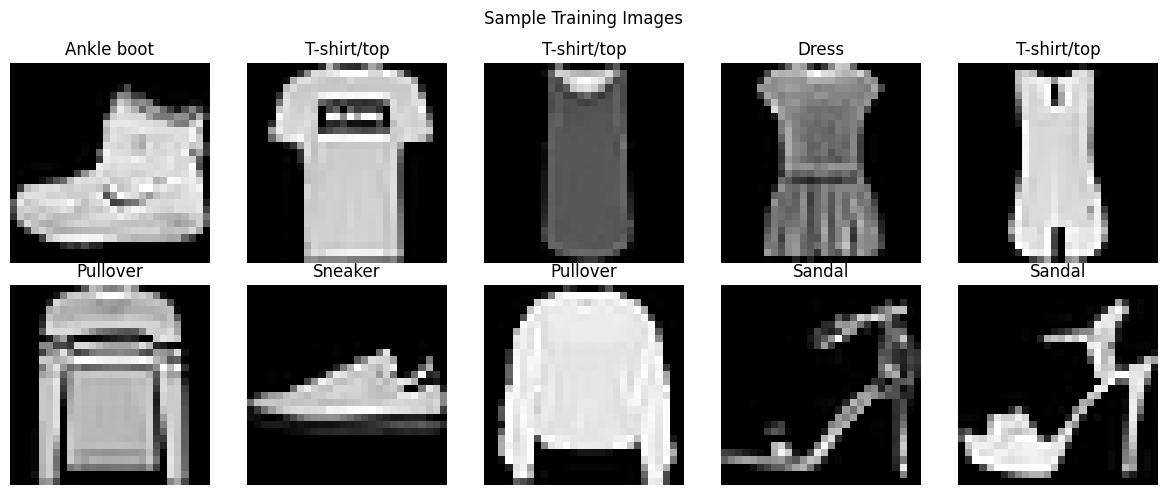

In [2]:
# ── Preprocessing ─────────────────────────────────────
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)
print("Shape after reshape:", x_train.shape)

# Sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[idx]]); ax.axis('off')
plt.suptitle("Sample Training Images"); plt.tight_layout(); plt.show()


In [3]:
# ── Build CNN Model ───────────────────────────────────
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10,  activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


d:\DL Practicals\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ── Training ──────────────────────────────────────────
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1
)

history = model.fit(
    x_train, y_train,
    epochs=20, batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint], verbose=1
)
print(f"\nTraining stopped at epoch {len(history.history['loss'])}")


Epoch 1/20
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7108 - loss: 0.7788
Epoch 1: val_accuracy improved from None to 0.85200, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.7905 - loss: 0.5670 - val_accuracy: 0.8520 - val_loss: 0.3898
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8559 - loss: 0.3867
Epoch 2: val_accuracy improved from 0.85200 to 0.88190, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.8629 - loss: 0.3731 - val_accuracy: 0.8819 - val_loss: 0.3209
Epoch 3/20
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8799 - loss: 0.3282
Epoch 3: val_accuracy improved from 0.88190 to 0.88550, saving model to best_cnn_model.h5



Epoch 3: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8809 - loss: 0.3264 - val_accuracy: 0.8855 - val_loss: 0.3075
Epoch 4/20
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8877 - loss: 0.3036
Epoch 4: val_accuracy improved from 0.88550 to 0.89840, saving model to best_cnn_model.h5



Epoch 4: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8891 - loss: 0.3016 - val_accuracy: 0.8984 - val_loss: 0.2767
Epoch 5/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8953 - loss: 0.2837
Epoch 5: val_accuracy did not improve from 0.89840
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.8953 - loss: 0.2837 - val_accuracy: 0.8977 - val_loss: 0.2664
Epoch 6/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9000 - loss: 0.2680
Epoch 6: val_accuracy improved from 0.89840 to 0.90350, saving model to best_cnn_model.h5


...


Epoch 9: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 20ms/step - accuracy: 0.9103 - loss: 0.2410 - val_accuracy: 0.9099 - val_loss: 0.2456
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9138 - loss: 0.2275
Epoch 10: val_accuracy improved from 0.90990 to 0.91000, saving model to best_cnn_model.h5



Epoch 10: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 105s 56ms/step - accuracy: 0.9108 - loss: 0.2347 - val_accuracy: 0.9100 - val_loss: 0.2436
Epoch 11/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9138 - loss: 0.2210
Epoch 11: val_accuracy did not improve from 0.91000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9136 - loss: 0.2275 - val_accuracy: 0.9042 - val_loss: 0.2656
Epoch 12/20
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9157 - loss: 0.2207
Epoch 12: val_accuracy did not improve from 0.91000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9158 - loss: 0.2207 - val_accuracy: 0.9077 - val_loss: 0.2550
Epoch 13/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9188 - loss: 0.2147
Epoch 13: val_accuracy improved from 0.91000 to 0.91070, saving model to best_cnn_model.h5



Epoch 13: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9170 - loss: 0.2230 - val_accuracy: 0.9107 - val_loss: 0.2413
Epoch 14/20
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9222 - loss: 0.2068
Epoch 14: val_accuracy improved from 0.91070 to 0.91090, saving model to best_cnn_model.h5



Epoch 14: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 41ms/step - accuracy: 0.9194 - loss: 0.2141 - val_accuracy: 0.9109 - val_loss: 0.2483
Epoch 15/20
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9208 - loss: 0.2059
Epoch 15: val_accuracy did not improve from 0.91090
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9204 - loss: 0.2100 - val_accuracy: 0.9094 - val_loss: 0.2530
Epoch 16/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9252 - loss: 0.1989
Epoch 16: val_accuracy improved from 0.91090 to 0.91270, saving model to best_cnn_model.h5



Epoch 16: finished saving model to best_cnn_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9222 - loss: 0.2068 - val_accuracy: 0.9127 - val_loss: 0.2526
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 13.

Training stopped at epoch 16


In [5]:
# ── E. Performance Metrics (Classification) ───────────
y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("E. PERFORMANCE METRICS")
print("=" * 50)
print(f"  Accuracy      : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (W) : {precision:.4f}")
print(f"  Recall    (W) : {recall:.4f}")
print(f"  F1-Score  (W) : {f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
E. PERFORMANCE METRICS
  Accuracy      : 0.9107  (91.07%)
  Precision (W) : 0.9107
  Recall    (W) : 0.9107
  F1-Score  (W) : 0.9102

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.90      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.83      0.90      0.86      1000
       Dress       0.91      0.92      0.91      1000
        Coat       0.88      0.82      0.85      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.76      0.70      0.73      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



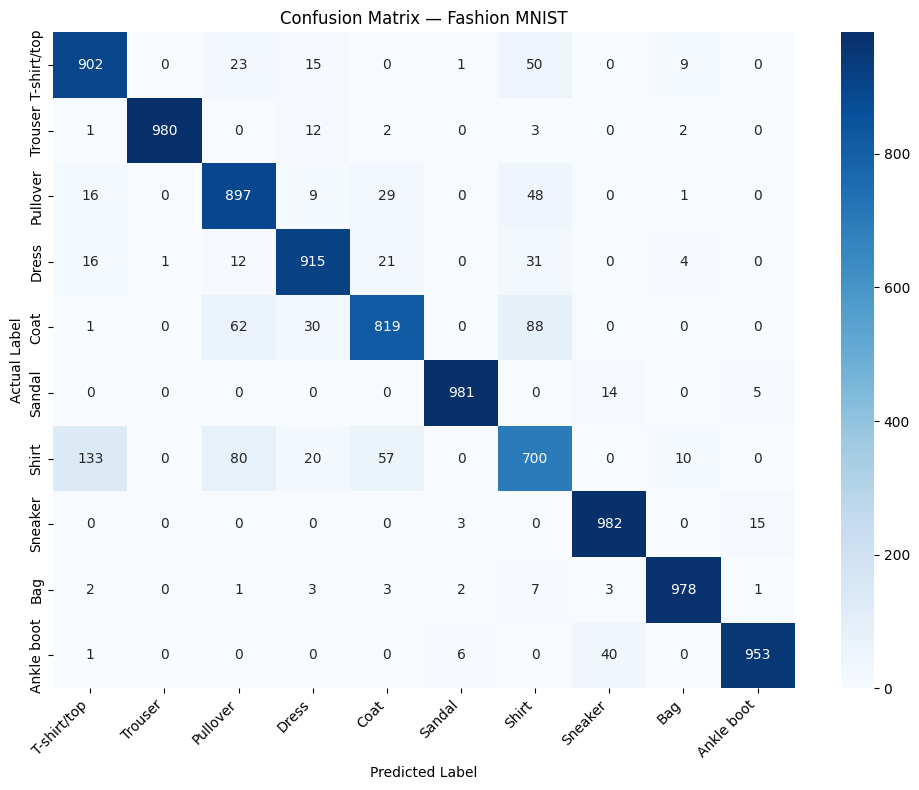

In [6]:
# ── Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Fashion MNIST")
plt.xlabel("Predicted Label"); plt.ylabel("Actual Label")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


## F. Training Behavior

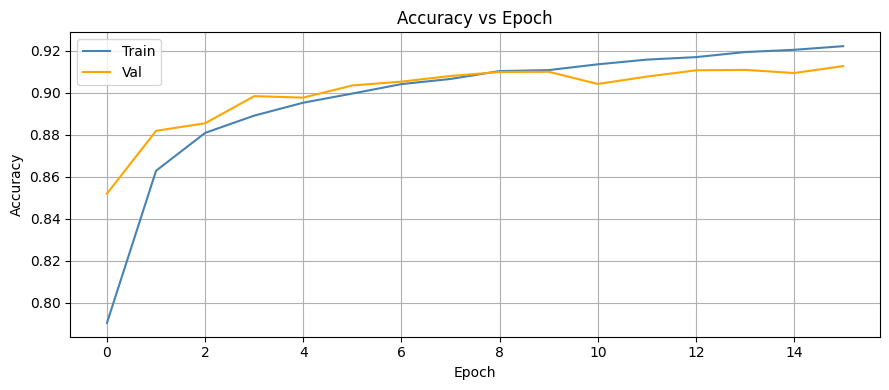

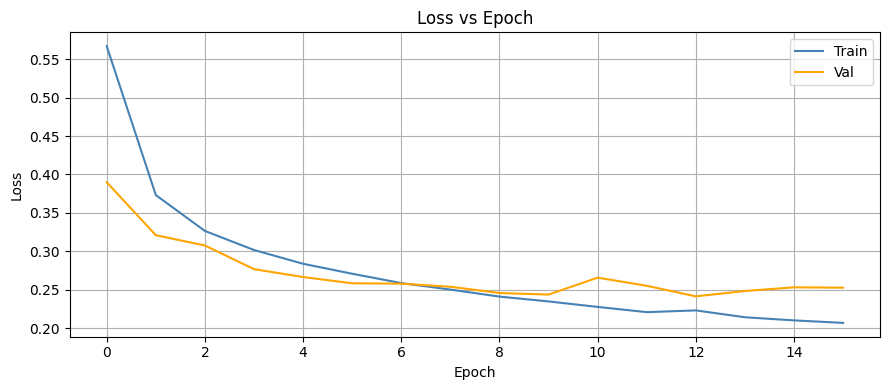

In [7]:
# ── F. Accuracy vs Epoch ──────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(history.history['accuracy'],     label='Train', color='steelblue')
plt.plot(history.history['val_accuracy'], label='Val',   color='orange')
plt.title("Accuracy vs Epoch"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ── F. Loss vs Epoch ──────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Train', color='steelblue')
plt.plot(history.history['val_loss'], label='Val',   color='orange')
plt.title("Loss vs Epoch"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


## G. Sample Predictions

#              Actual       Predicted   Confidence  Match
----------------------------------------------------------
1          Ankle boot      Ankle boot      99.99%      ✓
2            Pullover        Pullover      99.99%      ✓
3             Trouser         Trouser     100.00%      ✓
4             Trouser         Trouser     100.00%      ✓
5               Shirt           Shirt      61.82%      ✓
6             Trouser         Trouser     100.00%      ✓
7                Coat            Coat      99.37%      ✓
8               Shirt           Shirt      97.32%      ✓
9              Sandal          Sandal     100.00%      ✓
10            Sneaker         Sneaker     100.00%      ✓


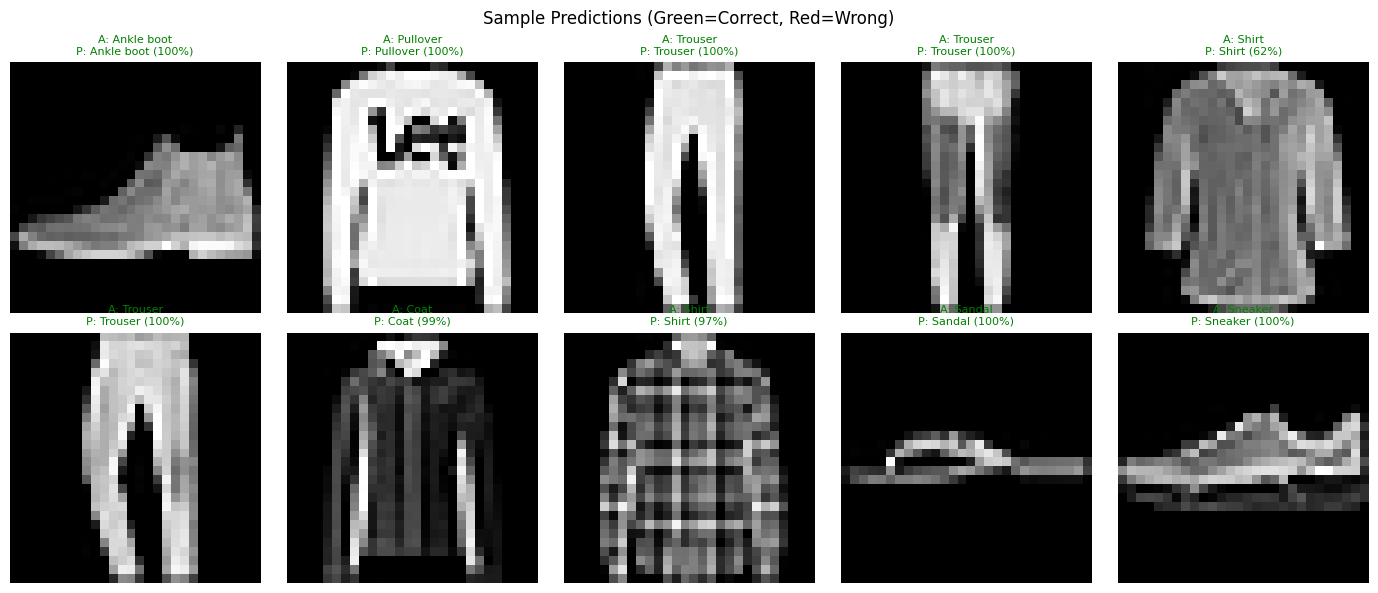

In [8]:
# ── G. Sample Predictions ─────────────────────────────
print(f"{'#':<5} {'Actual':>15} {'Predicted':>15} {'Confidence':>12} {'Match':>6}")
print("-" * 58)
for i in range(10):
    actual    = CLASS_NAMES[y_test[i]]
    predicted = CLASS_NAMES[y_pred[i]]
    conf      = y_prob[i][y_pred[i]]
    match     = "✓" if y_test[i] == y_pred[i] else "✗"
    print(f"{i+1:<5} {actual:>15} {predicted:>15} {conf:>11.2%} {match:>6}")

# Image grid with predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for idx, ax in enumerate(axes.flat):
    ax.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred[idx] == y_test[idx] else 'red'
    conf  = y_prob[idx][y_pred[idx]]
    ax.set_title(f"A: {CLASS_NAMES[y_test[idx]]}\nP: {CLASS_NAMES[y_pred[idx]]} ({conf:.0%})",
                 color=color, fontsize=8)
    ax.axis('off')
plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout(); plt.show()


## H. Observations / Analysis

1. **Overfitting/Underfitting:**
   - Dropout after every Conv block prevents co-adaptation of feature maps.
   - EarlyStopping with `restore_best_weights=True` retains the optimal checkpoint.

2. **Hyperparameter Effects:**
   - 3 Conv layers extract edges → textures → parts progressively.
   - Filter counts 32→64→128 increase representational depth at each stage.
   - Batch size 32 balances memory efficiency and gradient quality.

3. **Anomalies:**
   - Shirt vs T-shirt/top and Coat vs Pullover have the highest confusion rates.
   - CNN significantly outperforms a flat DNN on image data by exploiting spatial structure.
   - Accuracy >91% is typical for this architecture on Fashion MNIST.
